# Telecom Customer Churn Prediction using PySpark and XGBoost

**Author:** Suresh Sampath Manawadu  
**Programme:** MSc Data Science – Coventry University  

## Objective
Develop a scalable machine learning pipeline to predict telecom customer churn and compare Random Forest and XGBoost models.

## Workflow
EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Explainability

In [1]:
# Colab environment setup
!apt-get -qq update
!apt-get -qq install -y openjdk-11-jdk-headless > /dev/null
!pip -q install pyspark xgboost scikit-learn pandas matplotlib seaborn shap

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim, when, upper, sum as _sum

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, auc
)

import xgboost as xgb
import shap

In [3]:
# Start Spark

spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()
spark.sparkContext.setLogLevel("WARN")

In [4]:
# Upload and load datasets

from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = spark.read.csv(filename, header=True, inferSchema=True)

print("Rows:", df_raw.count())
df_raw.printSchema()
df_raw.show(5, truncate=False)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Rows: 7043
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (null

In [5]:
# Define Feature Groups

id_col = "customerID"
target_col = "Churn"

numeric_cols_eda = ["tenure", "MonthlyCharges", "TotalCharges"]

numeric_cols_model = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

yesno_cols = [
    "Partner", "Dependents", "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"
]

multi_cat_cols = ["gender", "InternetService", "Contract", "PaymentMethod"]

categorical_cols = yesno_cols + multi_cat_cols

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


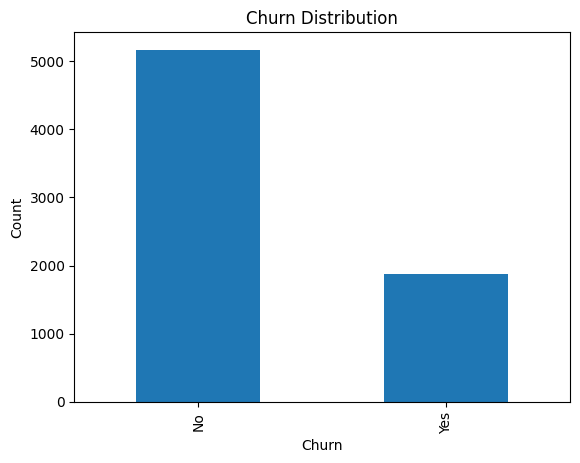

In [6]:
# Exploratory Data Analysis for Raw Data

df_pd_raw = df_raw.toPandas()

print(df_pd_raw.dtypes)

# Target distribution
df_pd_raw["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [7]:
# Check Missing values before cleaning

df_raw.select([
    _sum((col(c).isNull() | (trim(col(c)) == "")).cast("int")).alias(f"{c}_missing")
    for c in numeric_cols_eda
]).show()

+--------------+----------------------+--------------------+
|tenure_missing|MonthlyCharges_missing|TotalCharges_missing|
+--------------+----------------------+--------------------+
|             0|                     0|                  11|
+--------------+----------------------+--------------------+



In [8]:
# Data Preprocessing in Spark

df = df_raw.withColumn("TotalCharges", trim(col("TotalCharges")))

df = df.withColumn(
    "TotalCharges",
    when((col("TotalCharges") == "") | col("TotalCharges").isNull(), None)
    .otherwise(col("TotalCharges").cast("double"))
)

df = df.filter(col("tenure") > 0)
df = df.dropna(subset=["TotalCharges", "MonthlyCharges", "tenure", "Churn"])

In [9]:
# Validate Clean numerical fields

df.select([
    _sum((col(c).isNull()).cast("int")).alias(f"{c}_nulls")
    for c in ["tenure", "MonthlyCharges", "TotalCharges"]
]).show()

df.select("tenure", "MonthlyCharges", "TotalCharges").describe().show()

+------------+--------------------+------------------+
|tenure_nulls|MonthlyCharges_nulls|TotalCharges_nulls|
+------------+--------------------+------------------+
|           0|                   0|                 0|
+------------+--------------------+------------------+

+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7032|              7032|              7032|
|   mean|32.421786120591584| 64.79820819112632|2283.3004408418697|
| stddev|24.545259709263245|30.085973884049825| 2266.771361883145|
|    min|                 1|             18.25|              18.8|
|    max|                72|            118.75|            8684.8|
+-------+------------------+------------------+------------------+



In [10]:
# Check Data types

df_pd = df.toPandas()

print(df_pd.dtypes)

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


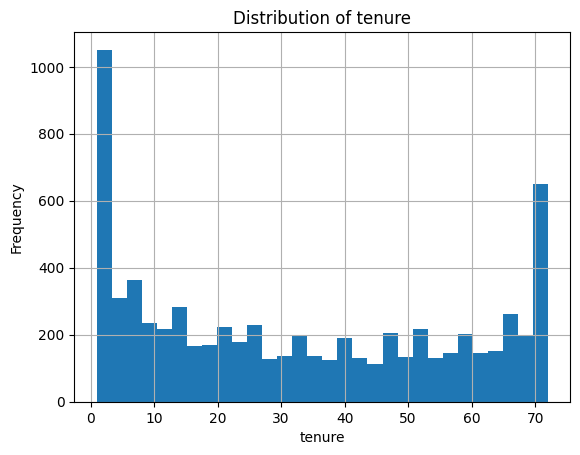

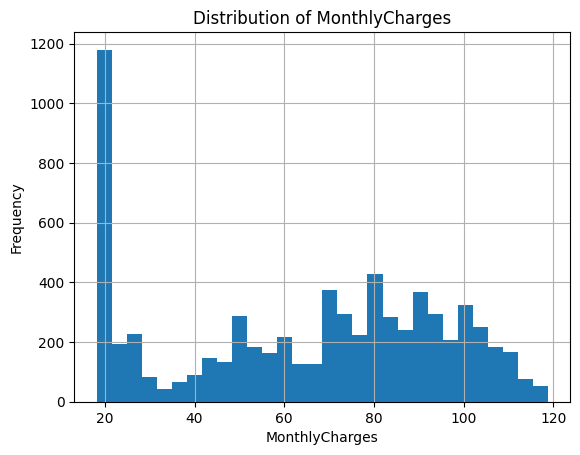

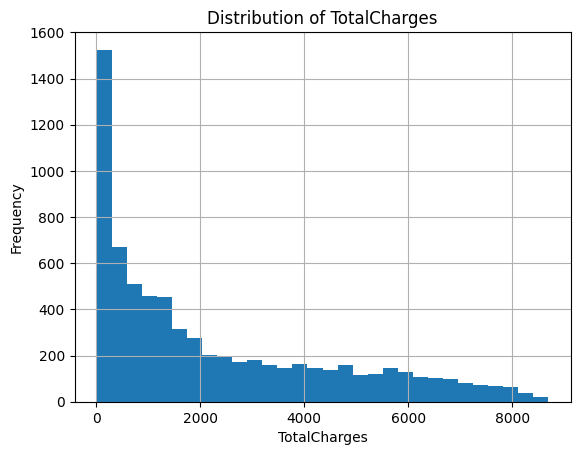

In [11]:
# Numerical Distribution

for col_name in numeric_cols_eda:
    df_pd[col_name].hist(bins=30)
    plt.title(f"Distribution of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Frequency")
    plt.show()

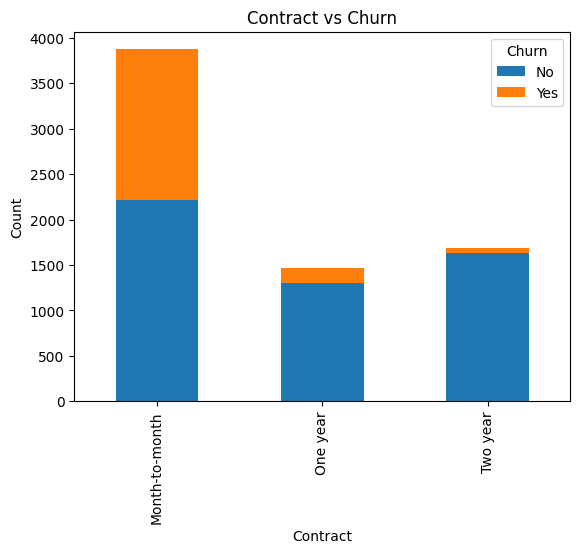

In [12]:
# Contract Vs Churn

pd.crosstab(df_pd["Contract"], df_pd["Churn"]).plot(kind="bar", stacked=True)
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

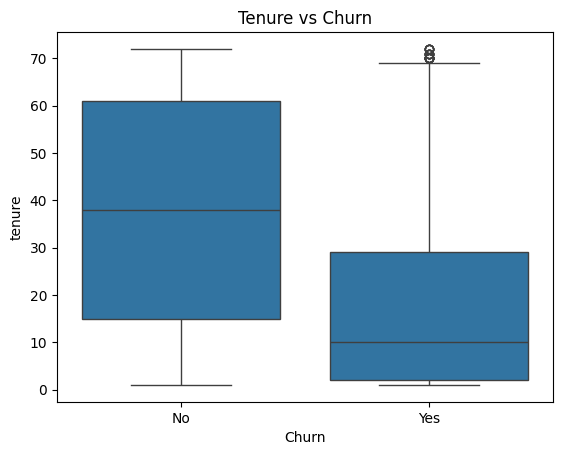

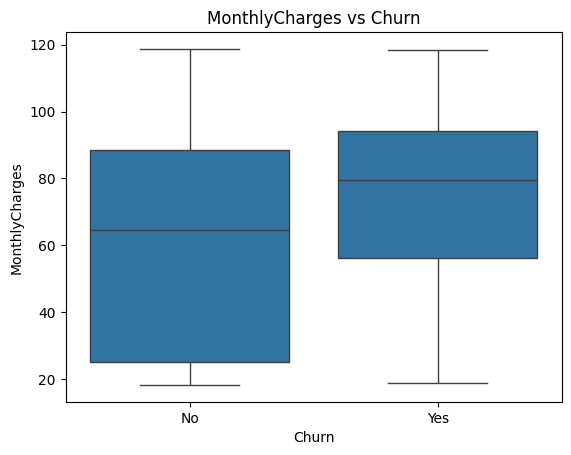

In [13]:
# Boxplots

sns.boxplot(x="Churn", y="tenure", data=df_pd)
plt.title("Tenure vs Churn")
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df_pd)
plt.title("MonthlyCharges vs Churn")
plt.show()

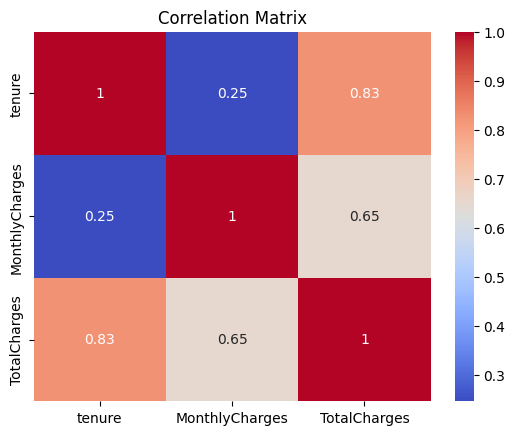

In [14]:
# Correlation Heatmap

corr = df_pd[numeric_cols_eda].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
# Label Creation

df = df.withColumn("Churn_clean", upper(trim(col("Churn"))))
df = df.filter(col("Churn_clean").isin("YES", "NO"))

df = df.withColumn(
    "label",
    when(col("Churn_clean") == "YES", 1.0).otherwise(0.0)
)

df.groupBy("label").count().orderBy("label").show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5163|
|  1.0| 1869|
+-----+-----+



In [16]:
# Feature Enginnering Pipeline

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_cols],
    outputCols=[f"{c}_oh" for c in categorical_cols],
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[f"{c}_oh" for c in categorical_cols] + numeric_cols_model,
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + [encoder, assembler])

pipe_model = pipeline.fit(df)
data = pipe_model.transform(df).select(id_col, "label", "features")

In [17]:
# Extract feature names for model interpretation and SHAP

def get_feature_names_from_metadata(df_spark, features_col="features"):
    meta = df_spark.schema[features_col].metadata
    attrs = []
    for group in ["binary", "numeric", "nominal"]:
        if "ml_attr" in meta and "attrs" in meta["ml_attr"] and group in meta["ml_attr"]["attrs"]:
            attrs.extend(meta["ml_attr"]["attrs"][group])
    attrs = sorted(attrs, key=lambda x: x["idx"])
    return [x["name"] for x in attrs]

feature_names = get_feature_names_from_metadata(data, "features")
print("Number of feature names:", len(feature_names))
print(feature_names[:10])

Number of feature names: 60
['Partner_oh_No', 'Partner_oh_Yes', 'Partner_oh___unknown', 'Dependents_oh_No', 'Dependents_oh_Yes', 'Dependents_oh___unknown', 'PhoneService_oh_Yes', 'PhoneService_oh_No', 'PhoneService_oh___unknown', 'MultipleLines_oh_No']


In [18]:
# Train/Test Split

train, test = data.randomSplit([0.7, 0.3], seed=42)

print("Train rows:", train.count())
print("Test rows :", test.count())

train.groupBy("label").count().orderBy("label").show()
test.groupBy("label").count().orderBy("label").show()

Train rows: 5028
Test rows : 2004
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3692|
|  1.0| 1336|
+-----+-----+

+-----+-----+
|label|count|
+-----+-----+
|  0.0| 1471|
|  1.0|  533|
+-----+-----+



In [19]:
# Random Forest Model

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

In [20]:
# Random Forest Evaluation

def eval_spark_classifier(pred_df, prediction_col="prediction"):
    acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol=prediction_col, metricName="accuracy"
    ).evaluate(pred_df)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol=prediction_col, metricName="f1"
    ).evaluate(pred_df)

    roc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(pred_df)

    return acc, f1, roc

rf_acc, rf_f1, rf_roc = eval_spark_classifier(rf_pred)

print("Random Forest")
print("Accuracy:", rf_acc)
print("F1      :", rf_f1)
print("ROC AUC :", rf_roc)

Random Forest
Accuracy: 0.8053892215568862
F1      : 0.7949157019731824
ROC AUC : 0.8556080470076326


In [21]:
# Random Forest – Class-Level Evaluation (Default Threshold = 0.5)

rf_pd_default = rf_pred.select("label", "prediction").toPandas()

y_true_rf_default = rf_pd_default["label"]
y_pred_rf_default = rf_pd_default["prediction"]

print(classification_report(y_true_rf_default, y_pred_rf_default))
print(confusion_matrix(y_true_rf_default, y_pred_rf_default))

              precision    recall  f1-score   support

         0.0       0.84      0.92      0.87      1471
         1.0       0.68      0.50      0.58       533

    accuracy                           0.81      2004
   macro avg       0.76      0.71      0.73      2004
weighted avg       0.79      0.81      0.79      2004

[[1347  124]
 [ 266  267]]


In [22]:
# Random Forest Feature Importance

rf_importances = rf_model.featureImportances.toArray()

fi_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

fi_rf.head(15)

,Feature,Importance
56,tenure,0.147890
58,TotalCharges,0.112259
47,Contract_oh_Month-to-month,0.095155
57,MonthlyCharges,0.069411
13,OnlineSecurity_oh_No,0.049768
51,PaymentMethod_oh_Electronic check,0.044287
43,InternetService_oh_Fiber optic,0.043892
48,Contract_oh_Two year,0.036656
25,TechSupport_oh_No,0.036337
44,InternetService_oh_DSL,0.021789


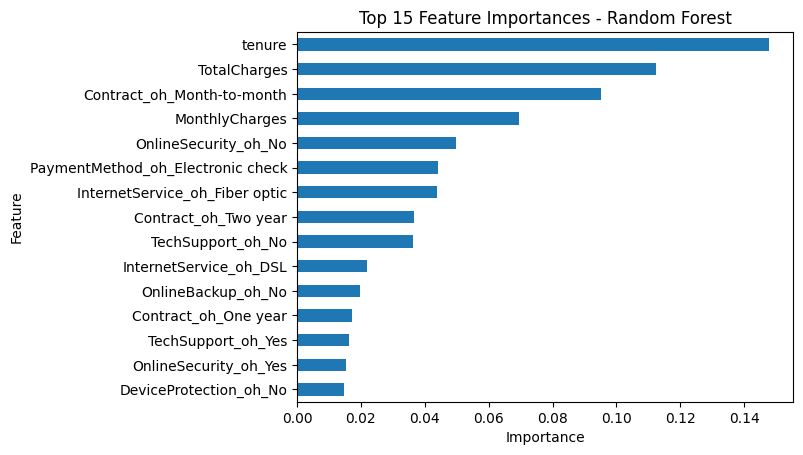

In [23]:
# Plot Random Forest Feature Importance

fi_rf.head(15).sort_values(by="Importance").plot(
    kind="barh", x="Feature", y="Importance", legend=False
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [24]:
# Prepare Pandas Matrices for XGBOOST and threshold-based evaluation

train_pd = train.toPandas()
test_pd = test.toPandas()

X_train = np.vstack(train_pd["features"].apply(lambda x: x.toArray()))
y_train = train_pd["label"].values

X_test = np.vstack(test_pd["features"].apply(lambda x: x.toArray()))
y_test = test_pd["label"].values

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2.7634730538922154


In [25]:
# Prepare Random Forest probabilities for tuned-threshold comparison

rf_prob = rf_pred.select("probability").toPandas()["probability"].apply(lambda x: float(x[1])).values

In [26]:
# XGBOOST GridSearch

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_df, y_train)

print("Best Params:", grid_search.best_params_)
print("Best ROC (CV):", grid_search.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best ROC (CV): 0.8392754237659084


In [27]:
# Find best XGBoost model

best_xgb = grid_search.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test_df)[:, 1]

In [28]:
# Threshold tuning function with fine search (0.01 step)

def evaluate_thresholds(y_true, y_prob):
    threshold_results = []

    for t in np.arange(0.10, 0.90, 0.01):
        y_pred_t = (y_prob >= t).astype(int)

        threshold_results.append({
            "Threshold": round(t, 2),
            "Accuracy": accuracy_score(y_true, y_pred_t),
            "Precision": precision_score(y_true, y_pred_t, zero_division=0),
            "Recall": recall_score(y_true, y_pred_t, zero_division=0),
            "F1": f1_score(y_true, y_pred_t, zero_division=0)
        })

    return pd.DataFrame(threshold_results)

In [29]:
# Fine threshold tuning for BOTH models

rf_threshold_df = evaluate_thresholds(y_test, rf_prob)
xgb_threshold_df = evaluate_thresholds(y_test, y_prob_xgb)

print("Random Forest threshold tuning:")
display(rf_threshold_df.sort_values(by="F1", ascending=False).head(10))

print("XGBoost threshold tuning:")
display(xgb_threshold_df.sort_values(by="F1", ascending=False).head(10))

Random Forest threshold tuning:


,Threshold,Accuracy,Precision,Recall,F1
28,0.38,0.802395,0.613223,0.696060,0.652021
30,0.40,0.808383,0.630931,0.673546,0.651543
20,0.30,0.770459,0.546616,0.803002,0.650456
19,0.29,0.765968,0.539604,0.818011,0.650261
26,0.36,0.793912,0.593168,0.716698,0.649108
18,0.28,0.762475,0.534629,0.825516,0.648968
29,0.39,0.803393,0.618399,0.681051,0.648214
27,0.37,0.797405,0.602254,0.701689,0.648180
21,0.31,0.773453,0.552318,0.782364,0.647516
31,0.41,0.809381,0.637523,0.656660,0.646950


XGBoost threshold tuning:


,Threshold,Accuracy,Precision,Recall,F1
41,0.51,0.765968,0.539702,0.816135,0.649739
42,0.52,0.767964,0.542929,0.806754,0.649057
49,0.59,0.788922,0.581845,0.733583,0.648963
40,0.50,0.763473,0.536108,0.821764,0.648889
48,0.58,0.785429,0.574746,0.742964,0.648118
50,0.60,0.791916,0.588957,0.720450,0.648101
39,0.49,0.760479,0.531889,0.829268,0.648094
43,0.53,0.769960,0.546512,0.793621,0.647284
38,0.48,0.757485,0.527877,0.834897,0.646802
51,0.61,0.793413,0.593114,0.711069,0.646758


In [30]:
# Select best thresholds based on F1

rf_best_threshold = rf_threshold_df.sort_values(by="F1", ascending=False).iloc[0]["Threshold"]
xgb_best_threshold = xgb_threshold_df.sort_values(by="F1", ascending=False).iloc[0]["Threshold"]

print("Best Random Forest threshold:", rf_best_threshold)
print("Best XGBoost threshold      :", xgb_best_threshold)

Best Random Forest threshold: 0.38
Best XGBoost threshold      : 0.51


In [31]:
# Final predictions at tuned thresholds

y_pred_rf_tuned = (rf_prob >= rf_best_threshold).astype(int)
y_pred_xgb_tuned = (y_prob_xgb >= xgb_best_threshold).astype(int)

In [42]:
# Evaluation function including PR-AUC

def evaluate_binary_model(name, y_true, y_pred, y_prob):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": pr_auc
    }

    print(name)
    print("Accuracy :", results["Accuracy"])
    print("Precision:", results["Precision"])
    print("Recall   :", results["Recall"])
    print("F1       :", results["F1"])
    print("ROC AUC  :", results["ROC AUC"])
    print("PR AUC   :", results["PR AUC"])

    return results

In [33]:
# Final Random Forest evaluation at tuned threshold

rf_tuned_results = evaluate_binary_model(
    "Random Forest (Tuned Threshold)",
    y_test,
    y_pred_rf_tuned,
    rf_prob
)

Random Forest (Tuned Threshold)
Accuracy : 0.8023952095808383
Precision: 0.6132231404958678
Recall   : 0.6960600375234521
F1       : 0.6520210896309314
ROC AUC  : 0.8556080470076258
PR AUC   : 0.6766964857937485


In [35]:
# Random Forest – Class-Level Evaluation at tuned threshold

print(classification_report(y_test, y_pred_rf_tuned))
print(confusion_matrix(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

         0.0       0.88      0.84      0.86      1471
         1.0       0.61      0.70      0.65       533

    accuracy                           0.80      2004
   macro avg       0.75      0.77      0.76      2004
weighted avg       0.81      0.80      0.81      2004

[[1237  234]
 [ 162  371]]


In [36]:
# Final XGBoost evaluation at tuned threshold

xgb_tuned_results = evaluate_binary_model(
    "XGBoost (Tuned Threshold)",
    y_test,
    y_pred_xgb_tuned,
    y_prob_xgb
)

XGBoost (Tuned Threshold)
Accuracy : 0.7659680638722555
Precision: 0.5397022332506204
Recall   : 0.8161350844277674
F1       : 0.6497386109036595
ROC AUC  : 0.856432619129308
PR AUC   : 0.6835509999710381


In [37]:
# XGBoost – Class-Level Evaluation at tuned threshold

print(classification_report(y_test, y_pred_xgb_tuned))
print(confusion_matrix(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

         0.0       0.92      0.75      0.82      1471
         1.0       0.54      0.82      0.65       533

    accuracy                           0.77      2004
   macro avg       0.73      0.78      0.74      2004
weighted avg       0.82      0.77      0.78      2004

[[1100  371]
 [  98  435]]


In [38]:
# Model Comparison using tuned thresholds for BOTH models

results = pd.DataFrame([
    rf_tuned_results,
    xgb_tuned_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Random Forest (Tuned Threshold),0.802395,0.613223,0.696060,0.652021,0.855608,0.676696
1,XGBoost (Tuned Threshold),0.765968,0.539702,0.816135,0.649739,0.856433,0.683551


 96%|=================== | 1925/2004 [00:13<00:00]       

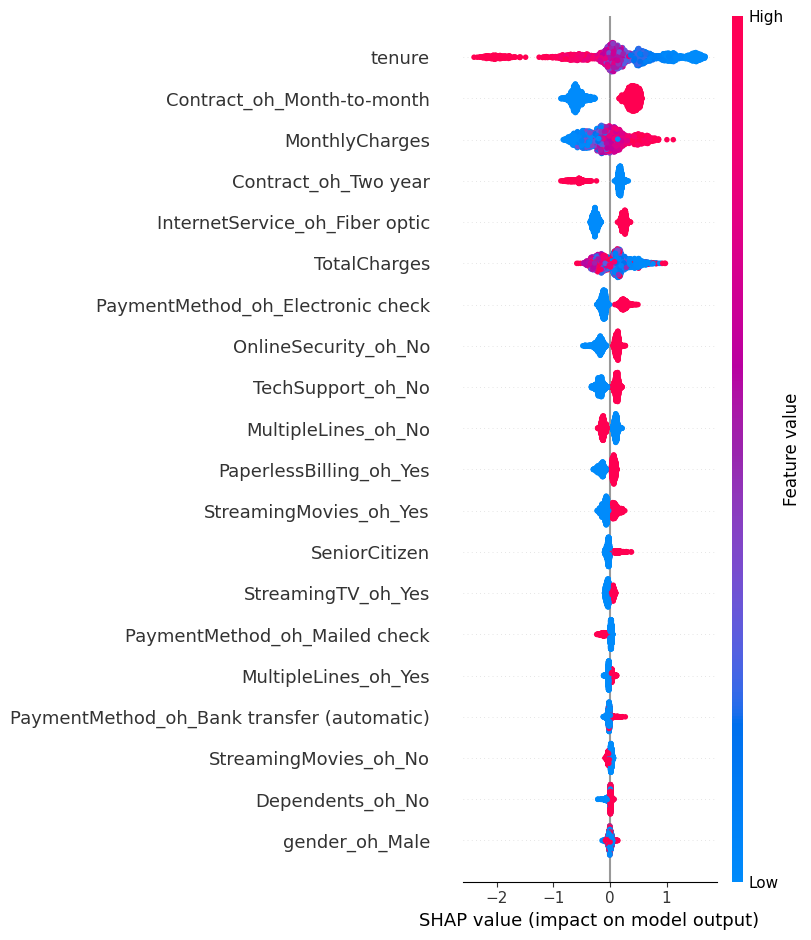

In [39]:
# SHAP with Generic Names

explainer = shap.Explainer(best_xgb, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

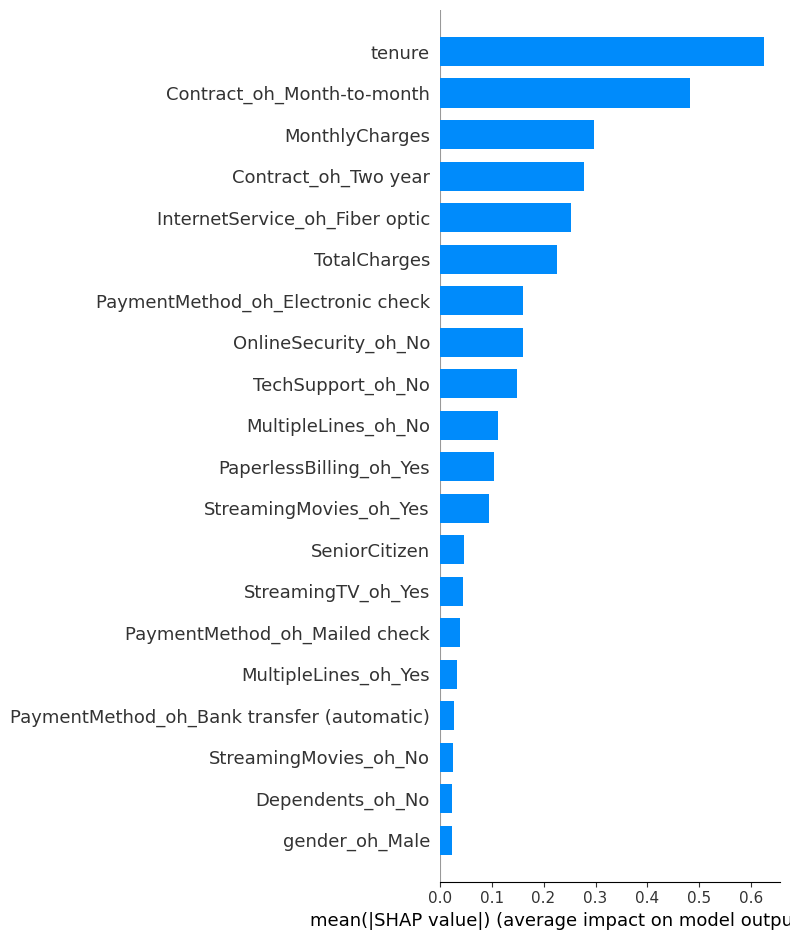

In [40]:
# SHAP bar plot

shap.summary_plot(shap_values, X_test_df, plot_type="bar")

##Conclusion

This project developed a scalable end-to-end telecom churn prediction pipeline using PySpark for data processing and feature engineering, and compared Random Forest and XGBoost models under a business-aligned evaluation framework.

### Key Contributions
- Performed structured EDA to understand customer behaviour and class imbalance
- Implemented robust preprocessing, including handling missing values and correcting data types (TotalCharges)
- Built a scalable Spark ML pipeline with indexing, one-hot encoding, and vector assembly
- Trained and evaluated two models:
- Random Forest (baseline, stable performance)
- XGBoost (advanced model with imbalance handling via scale_pos_weight)
- Applied fine-grained threshold optimisation (0.01 steps) instead of relying on default classification thresholds
- Used PR-AUC alongside ROC-AUC for more reliable evaluation under class imbalance
- Ensured fair comparison by evaluating both models at their respective optimal thresholds
- Incorporated SHAP explainability using actual engineered feature names for better interpretability

### Model Performance Summary
| Model                 | Accuracy | Precision | Recall   | F1       | ROC AUC | PR AUC    |
| --------------------- | -------- | --------- | -------- | -------- | ------- | --------- |
| Random Forest (Tuned) | 0.80     | **0.61**  | 0.70     | **0.65** | 0.856   | 0.677     |
| XGBoost (Tuned)       | 0.77     | 0.54      | **0.82** | 0.65     | 0.856   | **0.684** |


### Key Insights
- Both models achieved similar overall classification capability (ROC-AUC ≈ 0.86, F1 ≈ 0.65)
- Random Forest delivered higher accuracy and precision, indicating fewer false positives
- XGBoost achieved significantly higher recall (0.82), identifying more customers at risk of churn
- XGBoost also achieved a slightly higher PR-AUC, confirming better performance on the minority (churn) class

###Business Interpretation

In telecom churn prediction, the cost of missing a churner (false negative) is substantially higher than incorrectly flagging a non-churner (false positive).

- Random Forest provides more conservative predictions
- XGBoost provides better churn detection capability

Therefore, XGBoost is the preferred model for this use case, as it captures a larger proportion of at-risk customers, enabling more effective retention strategies.

### Final Note

The integration of threshold optimisation, PR-AUC evaluation, and explainability (SHAP) elevates this project from a standard classification task to a decision-focused, business-aligned machine learning solution.